<div style="display: flex; background-color: RGB(51,165,182);" >
<h1 style="margin: auto; padding: 20px; color:#fff; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px 

px.defaults.template='plotly_dark'
px.defaults.width = 600
px.defaults.height = 400

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium
#Afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)
#Afficher toutes les lignes d'un dataframe
pd.set_option('display.max_rows', None) 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("../Ressources/Data+Bottleneck/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("../Ressources/Data+Bottleneck/erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("../Ressources/Data+Bottleneck/liaison.xlsx")

c:\Users\saffr\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\saffr\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\saffr\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
df_erp['product_id'].duplicated().sum()

np.int64(0)

In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ? stock_quantity
df_erp['stock_status'].value_counts()

stock_status
instock       733
outofstock     92
Name: count, dtype: int64

In [10]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x == 0 else 'instock')


In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
5       True
6       True
7       True
8       True
9       True
10      True
11      True
12      True
13      True
14      True
15      True
16      True
17      True
18      True
19      True
20      True
21      True
22      True
23      True
24      True
25      True
26      True
27      True
28      True
29      True
30      True
31      True
32      True
33      True
34      True
35      True
36      True
37      True
38      True
39      True
40      True
41      True
42      True
43      True
44      True
45      True
46      True
47      True
48      True
49      True
50      True
51      True
52      True
53      True
54      True
55      True
56      True
57      True
58      True
59      True
60      True
61      True
62      True
63      True
64      True
65      True
66      True
67      True
68      True
69      True
70      True
71      True
72      True
73      True
74      True
75      True
76      True

In [12]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
sum(df_erp["stock_status"] == df_erp["stock_status_2"])

821

In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [14]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"], "stock_status"] = df_erp["stock_status_2"]
#Verification en utilisant le même code que plus haut pour afficher les problemes
sum(df_erp["stock_status"] == df_erp["stock_status_2"])

825

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp[df_erp["price"].isnull()].shape[0]))
#Afficher le prix minimum de la colonne "price"
print("Prix minimum: {}".format(df_erp["price"].min()))
#Afficher le prix maximum de la colonne "price"
print("Prix maximum: {}".format(df_erp["price"].max()))
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp_neg_price = df_erp[df_erp["price"] < 0]
df_erp_neg_price

Nombres d'article avec un prix non renseignés: 0
Prix minimum: -20.0
Prix maximum: 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [16]:
#Vérifions s'il existe une autre ligne où le prix de ces product_id est différent
for i in range(df_erp_neg_price.shape[0]) :
    prod_id = df_erp_neg_price.iloc[i]["product_id"]
    display(df_erp[df_erp["product_id"]==prod_id])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
469,5017,0,-8.0,0,outofstock,4.34,outofstock


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
739,6594,0,-9.1,19,instock,4.61,instock


In [17]:
#Ce n'est pas le cas, il faut donc supprimer ces lignes  
df_erp = df_erp[df_erp["price"] >= 0]
display(df_erp[df_erp["price"] < 0])
print("Il reste {} lignes dans le dataset".format(df_erp.shape[0]))

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


Il reste 822 lignes dans le dataset


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [18]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum: {}".format(df_erp["stock_quantity"].min()))
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum: {}".format(df_erp["stock_quantity"].max()))
#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp_neg_stock = df_erp[df_erp["stock_quantity"] < 0]
df_erp_neg_stock

Quantité minimum: -10
Quantité maximum: 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,instock,4.96,instock
573,5700,1,44.5,-1,instock,22.30,instock


In [19]:
#Vérifions s'il existe une autre ligne où le stock de ces product_id est différent
for i in range(df_erp_neg_stock.shape[0]) :
    prod_id = df_erp_neg_stock.iloc[i]["product_id"]
    display(df_erp[df_erp["product_id"]==prod_id])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,instock,4.96,instock


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
573,5700,1,44.5,-1,instock,22.3,instock


In [20]:
#Ce n'est pas le cas, il faut donc supprimer ces lignes
df_erp = df_erp[df_erp["stock_quantity"] >= 0]
display(df_erp[df_erp["stock_quantity"] < 0])
print("Il reste {} lignes dans le dataset".format(df_erp.shape[0]))

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


Il reste 820 lignes dans le dataset


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [21]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].value_counts()
#Booléen: 0(False : le produit n'est pas en vente sur le web) ou 1(True : le produit est en vente sur le web)

onsale_web
1    715
0    105
Name: count, dtype: int64

In [22]:
#Quelles sont les colonnes à conserver selon vous?
#Toutes sauf la colonne "stock_status_2" qui est redondante avec la colonne "stock_status"

In [23]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns=["stock_status_2"], inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [24]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp[df_erp["purchase_price"].isnull()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [25]:
#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum: {}".format(df_erp["purchase_price"].min()))
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum: {}".format(df_erp["purchase_price"].max()))

Prix minimum: 2.74
Prix maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [26]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [27]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [28]:
#Selon vous, quelles sont les colonnes à conserver ?
#virtual, downloadable, rating_count, average_rating, tax_class, post_author, post_date, post_date_gmt, post_content, post_excerpt, post_status, comment_status, ping_status, post_password, post_modified, post_modified_gmt, post_content_filtered, post_parent, guid, menu_order, post_type, post_mime_type, comment_count car elles ne sont pas pertinentes à l'analyse en court

In [29]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web.drop(columns=["virtual", "downloadable", "rating_count", "average_rating", "tax_class", "post_author", "post_date", "post_date_gmt", "post_content", "post_excerpt", "post_status", "comment_status", "ping_status", "post_password", "post_modified", "post_modified_gmt", "post_content_filtered", "post_parent", "guid", "menu_order", "post_type", "post_mime_type", "comment_count"], inplace=True)

In [30]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Afficher les 5 premières lignes de la table
df_web.head()

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


,sku,total_sales,tax_status,product_type,post_title,post_name
0,11862,3.0,NaN,Vin,Gilles Robin Hermitage Rouge 2012,gilles-robin-hermitage-2012
1,16057,5.0,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,pelle-sancerre-rouge-la-croix-au-garde-2017
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,fonreaud-bordeaux-blanc-le-cygne-2016
3,16295,14.0,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017,agnes-levet-cote-rotie-maestria-2017


In [31]:
#Afficher le type de la colonne "sku"
print("Type de la colonne sku: {}".format(df_web["sku"].dtype))

Type de la colonne sku: object


In [32]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?

In [33]:
#Identifier les lignes sans code articles
df_web[df_web["sku"].isnull()].head()

,sku,total_sales,tax_status,product_type,post_title,post_name
8,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_null = df_web[df_web["sku"].isnull()]
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_web_null.info()
#3 - Que constatez-vous?
#Il n'y a que 2 lignes sans code article et toutes les autres colonnes sont vides

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   tax_status    2 non-null      object 
 3   product_type  2 non-null      object 
 4   post_title    2 non-null      object 
 5   post_name     2 non-null      object 
dtypes: float64(1), object(5)
memory usage: 4.6+ KB


In [35]:
df_web[df_web["sku"].isnull() & ~df_web["post_title"].isnull()]

,sku,total_sales,tax_status,product_type,post_title,post_name
1084,NaN,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018
1087,NaN,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017


In [36]:
display(df_web[df_web["post_title"]=="Pierre Jean Villa Condrieu Jardin Suspendu 2018"])
display(df_web[df_web["post_title"]=="Pierre Jean Villa Côte Rôtie Fongeant 2017"])

,sku,total_sales,tax_status,product_type,post_title,post_name
1084,NaN,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018


,sku,total_sales,tax_status,product_type,post_title,post_name
1087,NaN,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017


In [37]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
df_web = df_web[~df_web["sku"].isnull()]
print("Il reste {} lignes dans le dataset".format(df_web.shape[0]))
df_web[df_web["sku"].isnull()]["post_title"].value_counts()

Il reste 1428 lignes dans le dataset


Series([], Name: count, dtype: int64)

In [38]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
df_web_duplicates = df_web[df_web["sku"].duplicated()]
print("Nombre de valeurs en double dans la colonne sku: {}".format(df_web_duplicates.shape[0]))

Nombre de valeurs en double dans la colonne sku: 714


In [39]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
df_web_duplicates.head()

,sku,total_sales,tax_status,product_type,post_title,post_name
56,12869,7.0,NaN,Vin,Stéphane Tissot Arbois D.D. 2016,stephane-tissot-arbois-dd-2016
74,13809,8.0,taxable,Vin,Antoine-Marie Arena Vin de France Rouge San Gi...,antoine-marie-arena-vin-de-france-rouge-san-gi...
109,15758,18.0,taxable,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,frissant-chenin-pierres-2018
117,13766,2.0,NaN,Whisky,Wemyss Malts Blended Malt Scotch Whisky Treacl...,whisky-wemyss-treacle-chest
137,16580,8.0,taxable,Vin,Domaine Giudicelli Patrimonio Blanc 2019,domaine-giudicelli-patrimonio-blanc-2019


In [40]:
df_web[df_web["sku"] == 12869].head()

,sku,total_sales,tax_status,product_type,post_title,post_name
14,12869,7.0,taxable,Vin,Stéphane Tissot Arbois D.D. 2016,stephane-tissot-arbois-dd-2016
56,12869,7.0,NaN,Vin,Stéphane Tissot Arbois D.D. 2016,stephane-tissot-arbois-dd-2016


In [41]:
df_web["product_type"].value_counts()

product_type
Vin              1316
Champagne          56
Whisky             28
Cognac             16
Huile d'olive       6
Gin                 4
Autre               1
Name: count, dtype: int64

In [42]:
#Le nombre de lignes où product_type est NaN
print("Nombre de lignes où product_type est NaN: {}".format(df_web[df_web["product_type"].isnull()].shape[0]))

Nombre de lignes où product_type est NaN: 1


In [43]:
df_web[df_web["product_type"].isnull()]

,sku,total_sales,tax_status,product_type,post_title,post_name
1387,bon-cadeau-25-euros,7.0,taxable,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros


In [44]:
#On supprime les lignes où product_type est NaN
df_web = df_web[~df_web["product_type"].isnull()]
print("Il reste {} lignes dans le dataset".format(df_web.shape[0]))

Il reste 1427 lignes dans le dataset


In [45]:
df_web["tax_status"].value_counts()

tax_status
taxable    713
Name: count, dtype: int64

In [46]:
df_web.shape[0]

1427

In [47]:
#Pour chaque doublon, il y a une ligne avec tax_status = taxable et une ligne avec tax_status = NaN
#On supprime les lignes qui apparaissent dans df_web_duplicates et où tax_status est NaN, tout en veillant à garder la ligne avec le code article "bon-cadeau-25-euros" qui est un cas particulier
df_web = df_web[(df_web["sku"] == "bon-cadeau-25-euros") | ~((df_web["sku"].isin(df_web_duplicates["sku"])) & (df_web["tax_status"].isnull()))]
print("Il reste {} lignes dans le dataset".format(df_web.shape[0]))

Il reste 714 lignes dans le dataset


In [48]:
##Partie de obsolète, car on a déjà vérifié les doublons différemment plus haut
#
#
##On va vérifier si les doublons des sku correspondent à des lignes identiques ou pas. Si oui, on les supprime, sinon on les affiche pour les traiter.
#
##On stocke le nombre de doublons pas identiques
#count = 0
#
##On parcours df_web_duplicates
#for dupe in range(df_web_duplicates.shape[0]) :
#    sku = df_web_duplicates.iloc[dupe]["sku"]
#    #On crée un dataframe df_web_sku avec seulement les lignes qui correspondent au sku
#    df_web_sku = df_web[df_web["sku"]==sku]
#    #On crée un booléen pour savoir si les lignes sont identiques ou pas
#    b = True
#    #On parcours les lignes du dataframe df_web_sku
#    for i in range(1,df_web_sku.shape[0]) :
#        #On parcours les colonnes du dataframe df_web_sku
#        for j in range(df_web_sku.shape[1]) :
#            col = df_web.columns[j]
#            #On compare les valeurs de la colonne
#            if df_web_sku.iloc[i][col] != df_web_sku.iloc[0][col] :
#                print(col)
#                b = False
#    #Si b est False, alors le sku a des lignes différentes
#    #On affiche le dataframe df_web_sku
#    if b == False :
#        count += 1
#        display(df_web_sku)
#    #Sinon, on récupère les index des lignes du dataframe df_web_sku
#    #On supprime les lignes du dataframe df_web
#    else :
#        for i in range(1,df_web_sku.shape[0]) :
#            index = df_web[df_web["sku"]==sku].index[i]
#            df_web.drop(index=index, inplace=True)
#
#print("Il y a {} doublons où les valeurs diffèrent".format(count))
#
##Dans le cas du bon cadeau, la seule différence est la colonne product_type, on supprime la ligne où product_type est null
#df_web = df_web.drop(1387)
#
##Médiane de la colonne total_sales
#print(df_web["total_sales"].median())
#
##Parmis les 4 derniers doublons, je vais garder celui le plus proche de la médiane
#df_web = df_web.drop([523, 219, 452, 114])

In [49]:
# On réincrémente les index après avoir supprimé les doublons
df_web.reset_index(drop=True, inplace=True)

In [50]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 714 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [51]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [52]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [53]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
print("Nombre de valeurs en double dans la colonne product_id: {}".format(df_liaison["product_id"].duplicated().sum()))

Nombre de valeurs en double dans la colonne product_id: 0


In [54]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Nombre de valeurs en double dans la colonne id_web: {}".format(df_liaison["id_web"].duplicated().sum()))

Nombre de valeurs en double dans la colonne id_web: 90


In [55]:
#Avons-nous des articles sans correspondances?
print("Nombre d'articles sans correspondance: {}".format(df_liaison[df_liaison["id_web"].isnull()].shape[0]))
print("Nombre d'articles sans correspondance: {}".format(df_liaison[df_liaison["product_id"].isnull()].shape[0]))

Nombre d'articles sans correspondance: 91
Nombre d'articles sans correspondance: 0


In [56]:
df_liaison[df_liaison["id_web"].duplicated()].head()

,id_web,product_id
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
151,NaN,4233


In [57]:
df_liaison[df_liaison["id_web"].duplicated() & ~df_liaison["id_web"].isnull()]

,id_web,product_id


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [58]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, how="outer", left_on="product_id", right_on="product_id")
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1.0,24.2,16.0,instock,12.88,15298
1,3849,1.0,34.3,10.0,instock,17.54,15296
2,3850,1.0,20.8,0.0,outofstock,10.64,15300
3,4032,1.0,14.1,26.0,instock,6.92,19814
4,4039,1.0,46.0,3.0,instock,23.77,19815


In [59]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_merge.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_merge.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 7 colonne(s)


In [60]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_merge[df_merge["id_web"].isnull()|df_merge["product_id"].isnull()].shape[0]

91

In [61]:
#On regarde s'il y a des lignes incohérentes
df_merge[df_merge["id_web"].isnull()&df_merge["onsale_web"]==1]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
242,4594,1.0,144.0,0.0,outofstock,87.36,NaN
486,5070,1.0,84.7,0.0,outofstock,47.43,NaN
487,5075,1.0,43.3,0.0,outofstock,21.70,NaN


In [62]:
df_merge_web_null = df_merge[df_merge["id_web"].isnull()&df_merge["onsale_web"]==1]

for i in list(df_merge_web_null.index.values) :
    df_merge.at[i,"onsale_web"] = 0

In [63]:
#On vérifie que les lignes ont bien été modifiées
df_merge[df_merge.index.isin(df_merge_web_null.index.values)]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
242,4594,0.0,144.0,0.0,outofstock,87.36,NaN
486,5070,0.0,84.7,0.0,outofstock,47.43,NaN
487,5075,0.0,43.3,0.0,outofstock,21.70,NaN


In [64]:
df_merge[df_merge["id_web"].isnull()&df_merge["onsale_web"]==1]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [65]:
#Fusionnez les datasets df_merge et df_web
df = pd.merge(df_merge, df_web, how="left", left_on="id_web", right_on="sku")
df.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name
0,3847,1.0,24.2,16.0,instock,12.88,15298,15298,6.0,taxable,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,pierre-jean-villa-saint-joseph-preface-2018
1,3849,1.0,34.3,10.0,instock,17.54,15296,15296,9.0,taxable,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,pierre-jean-villa-saint-joseph-tilde-2017
2,3850,1.0,20.8,0.0,outofstock,10.64,15300,15300,0.0,taxable,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...
3,4032,1.0,14.1,26.0,instock,6.92,19814,19814,12.0,taxable,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,pierre-jean-villa-igp-gamine-2018
4,4039,1.0,46.0,3.0,instock,23.77,19815,19815,3.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,pierre-jean-villa-cote-rotie-carmina-2017


In [66]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 13 colonne(s)


In [67]:
#Avons-nous des lignes sans correspondances?
print("Nombre d'articles sans correspondance: {}".format(df[df["id_web"].isnull()].shape[0]))
print("Nombre d'articles sans correspondance: {}".format(df[df["sku"].isnull()].shape[0]))

Nombre d'articles sans correspondance: 91
Nombre d'articles sans correspondance: 111


In [68]:
df[df["sku"].isnull() & ~df["id_web"].isnull()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name
193,4289,0.0,22.8,0.0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaN,NaN
236,4568,0.0,21.5,0.0,outofstock,11.22,15065,NaN,NaN,NaN,NaN,NaN,NaN
241,4584,0.0,32.3,0.0,outofstock,17.36,14785,NaN,NaN,NaN,NaN,NaN,NaN
355,4741,0.0,12.4,0.0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaN,NaN
391,4864,0.0,8.3,0.0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,NaN
394,4869,0.0,17.2,0.0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaN,NaN
424,4921,0.0,13.8,0.0,outofstock,7.13,15608,NaN,NaN,NaN,NaN,NaN,NaN
425,4922,0.0,21.5,0.0,outofstock,10.55,15586,NaN,NaN,NaN,NaN,NaN,NaN
470,5018,0.0,15.4,0.0,outofstock,7.72,15272,NaN,NaN,NaN,NaN,NaN,NaN
473,5021,0.0,17.1,0.0,outofstock,8.92,15630,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
df.loc[df["sku"].isnull() & ~df["id_web"].isnull(),"id_web"] = float("nan")
#On vérifie que les lignes ont bien été modifiées
df[df["sku"].isnull() & ~df["id_web"].isnull()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name


In [70]:
print("Nombre d'articles sans correspondance: {}".format(df[df["id_web"].isnull()].shape[0]))
print("Nombre d'articles sans correspondance: {}".format(df[df["sku"].isnull()].shape[0]))

Nombre d'articles sans correspondance: 111
Nombre d'articles sans correspondance: 111


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

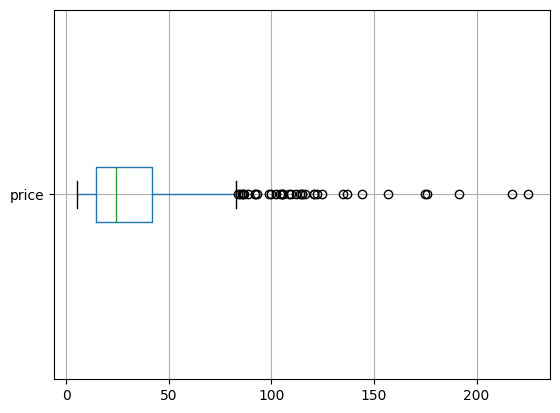

In [71]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt
df.boxplot(column="price", vert=False)
plt.show()

In [72]:
#Autre méthode avec plotly express
fig = px.box(df, x="price", orientation="h", labels={"price": "Prix (€)"},)
fig.update_layout(title="Répartition des prix", width=1000)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [73]:
#Calculer la moyenne du prix
mean_price = df["price"].mean()
print("Moyenne du prix: {:.2f}".format(mean_price))

#Calculer l'écart-type du prix
std_price = df["price"].std()
print("Ecart-type du prix: {:.2f}".format(std_price))

#Calculer le Z-score
df["z_score"] = (df["price"] - mean_price) / std_price
#Afficher les lignes avec un Z-score supérieur à 3
df_outliers_z_score = df[df["z_score"].abs() > 3]
#display(df_outliers)
print("Nombre de lignes avec un Z-score supérieur à 3: {}".format(df_outliers_z_score.shape[0]))


Moyenne du prix: 32.36
Ecart-type du prix: 26.64
Nombre de lignes avec un Z-score supérieur à 3: 17


In [74]:
#Quel est le seuil prix dont z-score est supérieur à 3?
threshold_price = mean_price + 3 * std_price
print("Seuil prix dont z-score est supérieur à 3: {:.2f}".format(threshold_price))

Seuil prix dont z-score est supérieur à 3: 112.28


In [75]:
df_outliers_z_score.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,z_score
count,17.000000,17.000000,17.000000,17.000000,17.000000,16.000000,17.000000
mean,5526.411765,0.941176,147.470588,23.882353,77.600588,4.125000,4.320847
std,734.996689,0.242536,36.686318,36.475818,24.872249,2.390955,1.377108
min,4352.000000,0.000000,114.000000,0.000000,52.250000,1.000000,3.064449
25%,4904.000000,1.000000,121.000000,11.000000,60.020000,3.000000,3.327211
50%,5892.000000,1.000000,135.000000,12.000000,67.950000,3.500000,3.852734
75%,6202.000000,1.000000,175.000000,16.000000,87.360000,5.000000,5.354229
max,6216.000000,1.000000,225.000000,138.000000,137.810000,11.000000,7.231098


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [76]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,z_score
count,825.000000,820.000000,820.000000,820.000000,820.000000,714.000000,8.200000e+02
mean,5162.597576,0.868293,32.362744,21.710976,16.987122,8.054622,-1.473076e-16
std,902.644635,0.338379,26.640110,21.932311,14.584113,4.161344,1.000000e+00
min,3847.000000,0.000000,5.200000,0.000000,2.740000,0.000000,-1.019618e+00
25%,4348.000000,1.000000,14.600000,7.000000,7.642500,5.000000,-6.667669e-01
50%,4907.000000,1.000000,24.400000,18.000000,12.740000,8.000000,-2.989006e-01
75%,5805.000000,1.000000,42.000000,30.000000,22.022500,11.000000,3.617574e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,36.000000,7.231098e+00


In [77]:
#Définissez un seuil pour les articles "outliers" en prix
#Inférieur à Q1 - 1.5 * IQR ou supérieur à Q3 + 1.5 * IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Seuil inférieur: {:.2f}".format(lower_bound))
print("Seuil supérieur: {:.2f}".format(upper_bound))

Seuil inférieur: -26.50
Seuil supérieur: 83.10


In [78]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_outliers_iqr = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
outliers_count = df_outliers_iqr.shape[0]
total_count = df.shape[0]
outliers_proportion = outliers_count / total_count * 100
print("Nombre d'articles outliers: {}".format(outliers_count))
print("Proportion d'articles outliers: {:.2f}%".format(outliers_proportion))

Nombre d'articles outliers: 36
Proportion d'articles outliers: 4.36%


In [79]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
#Pour démontrer si les outliers sont justifiés, on peut analyser les articles concernés
#On va afficher les articles concernés par les outliers
df_outliers_iqr.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name,z_score
19,4055,0.0,86.1,0.0,outofstock,37.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.017156
66,4115,1.0,100.0,12.0,instock,52.70,15382,15382,1.0,taxable,Vin,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,zind-humbrecht-riesling-gc-rangen-thann-clos-s...,2.538926
68,4132,1.0,88.4,7.0,instock,44.30,11668,11668,5.0,taxable,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2.103492
208,4352,1.0,225.0,0.0,outofstock,137.81,15940,15940,11.0,taxable,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,7.231098
214,4359,1.0,85.6,112.0,instock,51.93,13853,13853,7.0,taxable,Champagne,Champagne Larmandier-Bernier Grand Cru Les Che...,champagne-larmandier-bernier-grand-cru-vieille...,1.998387


In [80]:
df_outliers_iqr.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,z_score
count,36.000000,36.000000,36.000000,36.000000,36.000000,32.000000,36.000000
mean,5273.388889,0.888889,120.841667,25.277778,64.516667,4.125000,3.321267
std,766.539693,0.318728,36.254516,38.327619,23.024058,2.459347,1.360900
min,4055.000000,0.000000,83.700000,0.000000,37.880000,1.000000,1.927066
25%,4538.250000,1.000000,97.500000,9.000000,51.382500,2.000000,2.445082
50%,5048.000000,1.000000,110.800000,12.000000,56.435000,4.000000,2.944329
75%,5970.000000,1.000000,127.350000,17.250000,68.720000,6.000000,3.565573
max,6324.000000,1.000000,225.000000,138.000000,137.810000,11.000000,7.231098


In [81]:
#Graphique avec nuage de points comparant price et purchase_price
fig = px.scatter(df, x="price", y="purchase_price", hover_data=["post_title", "product_type"], labels={"price": "Prix de vente (€)", "purchase_price": "Prix d'achat (€)"})
fig.update_layout(title="Comparaison des prix d'achat et des prix de vente", width=1000, height=450)
fig.add_shape(type="line", x0=0, y0=0, x1=df["price"].max(), y1=df["price"].max()/2, line=dict(color="red", width=2))
fig.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [82]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article
df["ca_par_article"] = df["price"] * df["total_sales"]
#Calculez la somme de la colonne "ca_par_article"
total_ca = df["ca_par_article"].sum()
print("Le chiffre d'affaire total du site web est de {:.2f} €".format(total_ca))
#Ce résultat correspond au chiffre d'affaire du site web

Le chiffre d'affaire total du site web est de 143324.10 €


In [83]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df = df.sort_values(by="ca_par_article", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df.reset_index(drop=True, inplace=True)
#Afficher les 20 premier articles en CA
#display(df.head(20))
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df.head(20), x="ca_par_article", y="post_title", orientation="h", title="Top 20 des articles en CA", labels={"post_title": "Article", "ca_par_article": "CA (€)", "price" : "Prix (€)"}, hover_data=["price"], color="price", range_color=[0, df["price"].max()])
fig.update_layout(xaxis_title="CA (€)", yaxis_title="Article", width=1000, height=500)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [84]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df["part_ca"] = df["ca_par_article"] / total_ca
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df["cumsum_part_ca"] = df["part_ca"].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
n_articles_80_ca = df[df["cumsum_part_ca"] <= 0.8].shape[0]
print("Nombre d'articles représentant 80% du CA: {}".format(n_articles_80_ca))
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_ca = n_articles_80_ca / df.shape[0]
print("Proportion d'articles représentant 80% du CA: {:.2%}".format(proportion_articles_80_ca))

Nombre d'articles représentant 80% du CA: 433
Proportion d'articles représentant 80% du CA: 52.48%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [85]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df = df.sort_values(by="total_sales", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df.reset_index(drop=True, inplace=True)
#Afficher les 20 premier articles en quantité
#display(df.head(20))
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df.head(20), x="total_sales", y="post_title", orientation="h", title="Top 20 des articles en quantité", labels={"post_title": "Article", "total_sales": "Quantité vendue", "price" : "Prix (€)"}, hover_data=["price"], color="price", range_color=[0, df["price"].max()])
fig.update_layout(xaxis_title="Quantité vendue", yaxis_title="Article", width=1000, height=500)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [86]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df["part_quantity"] = df["total_sales"] / df["total_sales"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df["cumsum_part_quantity"] = df["part_quantity"].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
n_articles_80_quantity = df[df["cumsum_part_quantity"] <= 0.8].shape[0]
print("Nombre d'articles représentant 80% des ventes en quantité: {}".format(n_articles_80_quantity))
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_quantity = n_articles_80_quantity / df.shape[0]
print("Proportion d'articles représentant 80% des ventes en quantité: {:.2%}".format(proportion_articles_80_quantity))

Nombre d'articles représentant 80% des ventes en quantité: 433
Proportion d'articles représentant 80% des ventes en quantité: 52.48%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [87]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np
#Création de la colonne Mois de stock
df["rotation_stock"] = df["stock_quantity"] / df["total_sales"]
#Remplacement des "inf" par 0
df["rotation_stock"] = df["rotation_stock"].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df = df.sort_values(by="rotation_stock", ascending=False)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_temp = df[(df["rotation_stock"].notnull()) & (df["rotation_stock"] > 0) & (df["total_sales"] > 0)]
fig = px.bar(df_temp.tail(20), x="rotation_stock", y="post_title", orientation="h", title="Flop 20 des articles en mois de stock", labels={"post_title": "Article", "rotation_stock": "Mois de stock"}, hover_data=["price", "total_sales", "stock_quantity"])
fig.update_layout(xaxis_title="Mois de stock", yaxis_title="Article", width=1200, height=500)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [88]:
df["rotation_stock"].mean()

np.float64(2.9725483904465775)

In [89]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df["valorisation_stock_euros"] = df["stock_quantity"] * df["purchase_price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
total_valorisation_stock = df["valorisation_stock_euros"].sum()
print("La valorisation totale des stocks en euros est de {:.2f} €".format(total_valorisation_stock))

La valorisation totale des stocks en euros est de 298540.07 €


In [90]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_stock_quantity = df["stock_quantity"].sum()
print("Le nombre total de produits en stock est de {}".format(total_stock_quantity))

Le nombre total de produits en stock est de 17803.0


In [91]:
#Création d'un dataframe avec les produits en rupture de stock et ayant fait des ventes
df_outofstock = df[(df["stock_quantity"] == 0) & (df["total_sales"] > 0)]
print("Nombre de produits en rupture de stock ayant fait des ventes: {}".format(df_outofstock.shape[0]))
df_outofstock

Nombre de produits en rupture de stock ayant fait des ventes: 22


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name,z_score,ca_par_article,part_ca,cumsum_part_ca,part_quantity,cumsum_part_quantity,rotation_stock,valorisation_stock_euros
586,4636,1.0,50.00,0.0,outofstock,25.58,2361,2361,4.0,taxable,Vin,Marcel Windholtz Eau de Vie de Framboise d'Alsace,marcel-windholtz-eau-de-vie-de-framboise-dalsace,0.662056,200.00,0.001395,0.599283,0.000696,0.949226,0.0,0.0
521,4858,1.0,6.50,0.0,outofstock,3.19,16342,16342,5.0,taxable,Vin,Château Turcaud Bordeaux Rosé 2019,chateau-turcaud-rose-2019,-0.970820,32.50,0.000227,0.999905,0.000869,0.895844,0.0,0.0
461,4179,1.0,24.00,0.0,outofstock,13.02,16166,16166,6.0,taxable,Vin,Domaine de l'Hortus Pic Saint-Loup La Grande C...,hortus-pic-saint-loup-grande-cuvee-2018,-0.313916,144.00,0.001005,0.813561,0.001043,0.834464,0.0,0.0
458,6050,1.0,38.50,0.0,outofstock,20.09,15134,15134,6.0,taxable,Vin,Christophe Pichon Condrieu 2017,christophe-pichon-saint-condrieu-2017,0.230377,231.00,0.001612,0.486277,0.001043,0.831334,0.0,0.0
158,4352,1.0,225.00,0.0,outofstock,137.81,15940,15940,11.0,taxable,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,7.231098,2475.00,0.017269,0.017269,0.001913,0.374022,0.0,0.0
537,5709,1.0,31.70,0.0,outofstock,16.54,15035,15035,5.0,taxable,Vin,Philippe Alliet Chinon Rouge Coteau de Noiré 2016,alliet-chinon-rouge-noire-2016,-0.024878,158.50,0.001106,0.751515,0.000869,0.909755,0.0,0.0
446,4976,1.0,16.45,0.0,outofstock,8.07,16005,16005,7.0,taxable,Vin,Château Lafont Menaut Pessac-Leognan Rouge 2017,chateau-lafont-menaut-pessac-leognan-rouge-2017,-0.597323,115.15,0.000803,0.915868,0.001217,0.816901,0.0,0.0
247,4706,1.0,16.80,0.0,outofstock,8.68,15349,15349,10.0,taxable,Vin,Albert Mann Muscat 2018,albert-mann-muscat-2018,-0.584185,168.00,0.001172,0.713862,0.001739,0.534690,0.0,0.0
566,4612,1.0,20.60,0.0,outofstock,10.22,15038,15038,5.0,taxable,Vin,Gilbert Picq Chablis Vieilles Vignes 2017,gilbert-picq-chablis-vieilles-vignes-2017,-0.441543,103.00,0.000719,0.956910,0.000869,0.934968,0.0,0.0
48,5930,1.0,14.10,0.0,outofstock,6.92,16323,16323,14.0,taxable,Vin,Borie La Vitarèle Languedoc Blanc Le Grand May...,borie-la-vitarele-languedoc-blanc-grand-mayol-...,-0.685536,197.40,0.001377,0.607588,0.002434,0.139628,0.0,0.0


In [92]:
#Création d'un graphique en barre des produits en rupture de stock et ayant fait des ventes en affichant le nombre de ventes
fig = px.bar(df_outofstock, x="total_sales", y="post_title", orientation="h", title="Produits en rupture de stock ce mois-ci", labels={"post_title": "Article", "total_sales": "Nombre de ventes", "price" : "Prix (€)"}, hover_data=["price"], color="price", range_color=[0, df["price"].max()])
fig.update_layout(xaxis_title="Nombre de ventes", yaxis_title="Article", width=1200, height=500)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [93]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df["price_ht"] = df["price"] / 1.2  # Supposons que le taux de TVA est de 20%
#Création de la colonne Taux de marge
df["taux_marge"] = 100 * (df["price_ht"] - df["purchase_price"]) / df["purchase_price"]
#Afficher le pourcentage minimum de la colonne "taux_marge"
print("Pourcentage minimum de la colonne taux_marge: {:.2f}%".format(df["taux_marge"].min()))
#Afficher le pourcentage maximum de la colonne "taux_marge"
print("Pourcentage maximum de la colonne taux_marge: {:.2f}%".format(df["taux_marge"].max()))

Pourcentage minimum de la colonne taux_marge: -86.39%
Pourcentage maximum de la colonne taux_marge: 91.41%


In [94]:
#affichage de la ligne avec un taux de marge inférieur à 0
df[df["taux_marge"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_name,z_score,ca_par_article,part_ca,cumsum_part_ca,part_quantity,cumsum_part_quantity,rotation_stock,valorisation_stock_euros,price_ht,taux_marge
709,4355,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,taxable,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,-0.739965,0.0,0.0,1.0,0.0,1.0,0.0,7515.56,10.541667,-86.394338
741,4864,0.0,8.30,0.0,outofstock,9.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.903252,NaN,NaN,NaN,NaN,NaN,NaN,0.00,6.916667,-30.764097
769,6324,0.0,92.00,18.0,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.238626,NaN,NaN,NaN,NaN,NaN,NaN,1782.00,76.666667,-22.558923
819,7196,0.0,31.00,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.051154,NaN,NaN,NaN,NaN,NaN,NaN,1716.00,25.833333,-17.200855


In [95]:
#création d'un dataframe avec les taux positifs
df_positive_margin = df[df["taux_marge"] >= 0]
#Afficher le pourcentage minimum de la colonne "taux_marge"
print("Pourcentage minimum de la colonne taux_marge: {:.2f}%".format(df_positive_margin["taux_marge"].min()))
#Afficher le pourcentage maximum de la colonne "taux_marge"
print("Pourcentage maximum de la colonne taux_marge: {:.2f}%".format(df_positive_margin["taux_marge"].max()))

Pourcentage minimum de la colonne taux_marge: 29.50%
Pourcentage maximum de la colonne taux_marge: 91.41%


In [96]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_margin_by_product_type = df_positive_margin.groupby("product_type")["taux_marge"].mean().reset_index()
#Affichage dans un graphique du taux de marge par type de produit
#Ordonner les types de produits par taux de marge moyen
df_margin_by_product_type = df_margin_by_product_type.sort_values(by="taux_marge", ascending=False)
fig = px.bar(df_margin_by_product_type, x="product_type", y="taux_marge", title="Taux de marge moyen par type de produit", labels={"product_type": "Type de produit", "taux_marge": "Taux de marge (%)"})
fig.update_layout(xaxis_title="Type de produit", yaxis_title="Taux de marge (%)", width=1200, height=500)
fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

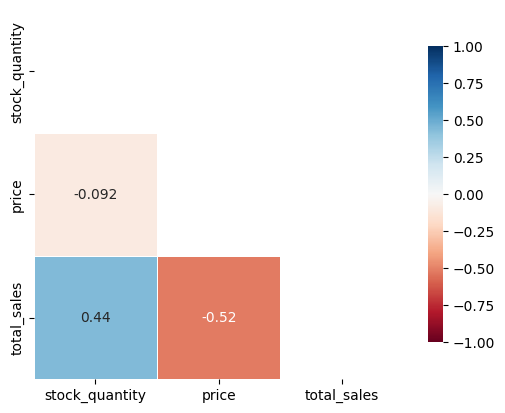

In [97]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns
#Sélectionner uniquement les colonnes numériques pour la corrélation
df_numeric = df.select_dtypes(include='number')
#On ne garde que les colonnes qui nous intéressent pour la heatmap
df_numeric = df_numeric[['stock_quantity', 'price', 'total_sales']]

#Création d'un heatmap de correlation entre les variables numériques
fig = px.imshow(df_numeric.corr(), text_auto=True, aspect="auto", color_continuous_scale='RdBu', title='Heatmap de corrélation entre les variables numériques')
#Changer le nom des variables pour qu'elles soient plus lisibles
fig.update_xaxes(ticktext=['Quantité en stock', 'Prix de vente', 'Ventes totales'], tickvals=[0, 1, 2])
fig.update_yaxes(ticktext=['Quantité en stock', 'Prix de vente', 'Ventes totales'], tickvals=[0, 1, 2])
#Réduire le nombre de décimales affichées
fig.update_traces(texttemplate='%{z:.2f}', textfont_size=12)
fig.update_layout(width=800, height=600)
fig.show()
#on peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_numeric.corr(), dtype=bool))
# Création de la heatmap avec le mask
sns.heatmap(df_numeric.corr(), annot=True, mask=mask, cmap='RdBu', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
# Affichage de la heatmap
plt.show()

In [98]:
#Que peut-on conclure des correlations ?
#Il y a une corrélation entre le stock quantity et le total sales, plus un produit est vendu, plus il y a de changement dans le stock.
#Il y a une corrélation entre le price et le total sales, plus un produit est cher, moins il est vendu.
#Il n'y a pas de corrélation entre le stock quantity et le price, le prix de vente n'influence pas le stock.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [99]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.
df.to_excel("../Ressources/Data+Bottleneck/data_Bottleneck.xlsx", index=False)